# Daily limit-order candidate deep dive

Build a candidate from walk-forward selections, then inspect its full-sample contribution-lot execution behavior.

In [1]:
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px

from retail_sp500.daily_data import daily_data_summary, load_or_fetch_twelve_data_daily

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

from retail_sp500.limit_portfolio import (
    RecurringLimitConfig,
    evaluate_recurring_limit_grid,
    simulate_recurring_limit_strategy,
    summarize_recurring_limit_result,
    walk_forward_recurring_limit_selection,
)

In [2]:
SYMBOL = "SPY"
START_DATE = "2007-06-01"
CACHE_PATH = Path("data/processed/spy_daily_1day.csv")
REFRESH = False

daily = load_or_fetch_twelve_data_daily(
    os.getenv("TWELVE_DATA_API_KEY"),
    cache_path=CACHE_PATH,
    refresh=REFRESH,
    symbol=SYMBOL,
    start_date=START_DATE,
)

source = daily_data_summary(daily, symbol=SYMBOL)
print(source)
assert source["interval"] == "1day"
assert daily.index.max() <= pd.Timestamp.today().normalize()
daily.tail()

{'source': 'CSV cache: data/processed/spy_daily_1day.csv', 'symbol': 'SPY', 'interval': '1day', 'start': '2007-06-01', 'end': '2026-07-14', 'sessions': 4809}


,open,high,low,close,volume
date,,,,,
2026-07-08,743.159970,746.150020,739.510010,745.400020,43767400
2026-07-09,747.349980,751.969970,745.590030,751.710020,41441700
2026-07-10,752.049988,755.419980,748.099976,754.950010,42191300
2026-07-13,752.469970,753.909970,748.000000,749.169980,44013600
2026-07-14,750.909970,753.299990,748.659970,751.830020,35135286


## Derive a candidate from out-of-sample selections

In [3]:
DISCOUNTS = np.arange(0.0, 0.0301, 0.001)
MAX_WAIT_SESSIONS = 5

walk_forward = walk_forward_recurring_limit_selection(
    daily,
    DISCOUNTS,
    train_years=5,
    test_years=1,
    max_wait_sessions=MAX_WAIT_SESSIONS,
    monthly_contribution=1_000,
)

CANDIDATE_DISCOUNT = float(walk_forward["selected_discount"].median())
CANDIDATE_DISCOUNT

0.0055

## Full-sample sensitivity around the candidate

In [4]:
nearby = DISCOUNTS[
    (DISCOUNTS >= max(0.0, CANDIDATE_DISCOUNT - 0.005))
    & (DISCOUNTS <= CANDIDATE_DISCOUNT + 0.005)
]

sensitivity = evaluate_recurring_limit_grid(
    daily,
    nearby,
    max_wait_sessions=MAX_WAIT_SESSIONS,
    initial_cash=100_000,
    monthly_contribution=1_000,
)

sensitivity.sort_values("ending_excess_value", ascending=False)

,discount,max_wait_sessions,lots,total_contributed,ending_value,baseline_ending_value,ending_excess_value,ending_excess_pct_of_contributions,limit_fill_rate,gap_fill_rate,touch_fill_rate,forced_fill_rate,average_wait_sessions,weighted_execution_savings_vs_immediate_open
9,0.010000,5,230,"329,000.000000","1,335,320.101836","1,331,887.362301","3,432.739535",0.010434,0.643478,0.143478,0.500000,0.356522,3.239130,0.001831
8,0.009000,5,230,"329,000.000000","1,335,100.802951","1,331,887.362301","3,213.440649",0.009767,0.691304,0.147826,0.543478,0.308696,3.004348,0.001739
6,0.007000,5,230,"329,000.000000","1,333,211.791312","1,331,887.362301","1,324.429011",0.004026,0.813043,0.160870,0.652174,0.186957,2.539130,0.000557
7,0.008000,5,230,"329,000.000000","1,333,011.454259","1,331,887.362301","1,124.091958",0.003417,0.739130,0.147826,0.591304,0.260870,2.839130,0.000311
5,0.006000,5,230,"329,000.000000","1,332,662.675584","1,331,887.362301",775.313283,0.002357,0.852174,0.200000,0.652174,0.147826,2.386957,0.000250
4,0.005000,5,230,"329,000.000000","1,331,864.739450","1,331,887.362301",-22.622851,-0.000069,0.891304,0.260870,0.630435,0.108696,2.260870,-0.000168
3,0.004000,5,230,"329,000.000000","1,331,628.384586","1,331,887.362301",-258.977715,-0.000787,0.917391,0.273913,0.643478,0.082609,2.021739,-0.000367
2,0.003000,5,230,"329,000.000000","1,331,342.613404","1,331,887.362301",-544.748897,-0.001656,0.965217,0.343478,0.621739,0.034783,1.786957,-0.000482
1,0.002000,5,230,"329,000.000000","1,331,288.835329","1,331,887.362301",-598.526973,-0.001819,0.995652,0.443478,0.552174,0.004348,1.604348,-0.000370
0,0.001000,5,230,"329,000.000000","1,331,196.118230","1,331,887.362301",-691.244071,-0.002101,1.000000,0.482609,0.517391,0.000000,1.508696,-0.000560


## Contribution-lot trace

In [5]:
lots = simulate_recurring_limit_strategy(
    daily,
    RecurringLimitConfig(
        discount=CANDIDATE_DISCOUNT,
        max_wait_sessions=MAX_WAIT_SESSIONS,
        initial_cash=100_000,
        monthly_contribution=1_000,
    ),
)

summarize_recurring_limit_result(lots)

{'lots': 230,
 'total_contributed': 329000.0,
 'ending_value': 1332294.2383578233,
 'baseline_ending_value': 1331887.3623011077,
 'ending_excess_value': 406.87605671561323,
 'ending_excess_pct_of_contributions': 0.0012367053395611345,
 'limit_fill_rate': 0.8826086956521739,
 'gap_fill_rate': 0.23478260869565218,
 'touch_fill_rate': 0.6478260869565218,
 'forced_fill_rate': 0.11739130434782609,
 'average_wait_sessions': 2.3217391304347825,
 'weighted_execution_savings_vs_immediate_open': 0.00015000246385699905}

In [6]:
lots[[
    "amount",
    "fill_date",
    "fill_type",
    "wait_sessions",
    "baseline_open_price",
    "fill_price",
    "execution_savings_vs_immediate_open",
    "ending_excess_value",
]].tail(24)

,amount,fill_date,fill_type,wait_sessions,baseline_open_price,fill_price,execution_savings_vs_immediate_open,ending_excess_value
contribution_date,,,,,,,,
2024-08-01,1000,2024-08-01,touch,1,552.570010,547.780545,0.008668,11.896323
2024-09-03,1000,2024-09-03,gap,1,560.469970,560.469970,0.000000,0.000000
2024-10-01,1000,2024-10-01,touch,1,573.400020,570.604330,0.004876,6.424154
2024-11-01,1000,2024-11-04,touch,2,571.320010,567.899258,0.005987,7.926665
2024-12-02,1000,2024-12-06,expiry_close,5,602.969970,607.810000,-0.008027,-9.928970
2025-01-02,1000,2025-01-02,touch,1,589.390010,582.856577,0.011085,14.298703
2025-02-03,1000,2025-02-03,gap,1,592.669980,592.669980,0.000000,0.000000
2025-03-03,1000,2025-03-03,touch,1,596.179990,590.912000,0.008836,11.242539
2025-04-01,1000,2025-04-01,touch,1,557.450010,556.313365,0.002039,2.755619


In [7]:
annual_execution = lots.assign(year=lots.index.year).groupby("year").agg(
    lots=("amount", "size"),
    contributed=("amount", "sum"),
    average_wait=("wait_sessions", "mean"),
    forced_fill_rate=("fill_type", lambda values: (values == "expiry_close").mean()),
    average_execution_savings=("execution_savings_vs_immediate_open", "mean"),
    ending_excess_value=("ending_excess_value", "sum"),
)

annual_execution

,lots,contributed,average_wait,forced_fill_rate,average_execution_savings,ending_excess_value
year,,,,,,
2007,7,106000,2.142857,0.142857,-0.002580,820.927094
2008,12,12000,1.416667,0.000000,-0.000265,3.119214
2009,12,12000,1.583333,0.000000,-0.000260,-26.823241
2010,12,12000,3.083333,0.250000,-0.008716,-686.419880
2011,12,12000,2.333333,0.000000,0.002592,180.297027
2012,12,12000,2.416667,0.083333,0.001107,77.770002
2013,12,12000,2.416667,0.000000,0.002358,128.202717
2014,12,12000,2.500000,0.083333,0.001507,71.591281
2015,12,12000,1.750000,0.000000,0.003470,155.783472


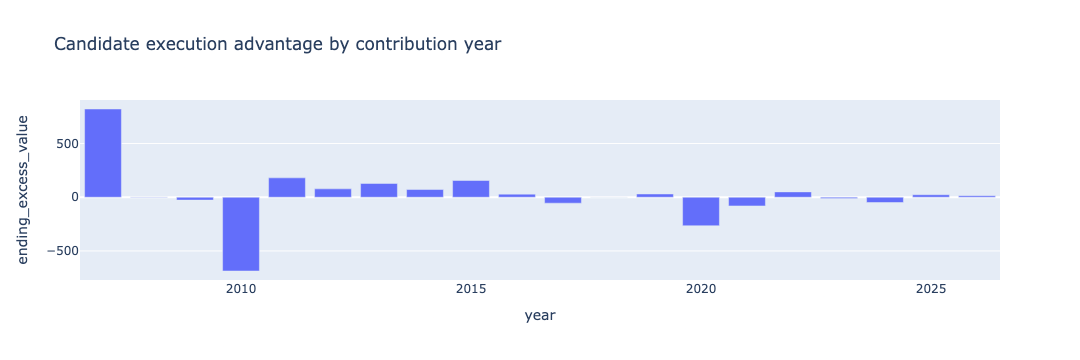

In [8]:
px.bar(
    annual_execution.reset_index(),
    x="year",
    y="ending_excess_value",
    title="Candidate execution advantage by contribution year",
).show()

## Remaining requirements before live use

Add dividends, cash yield, spreads, fees, taxes, order cut-off times, and a broker-specific order lifecycle. The candidate is a research result, not an instruction to trade.